## Results at a Glance

**One macro forecast, carried through to the three decisions it actually drives: rate
positioning, policy anticipation, and credit provisioning.**

Banks are exposed to inflation surprises on three fronts at once: mispriced rate risk when
a CPI forecast misses, mistimed positioning when an RBA move is misjudged, and understated
credit losses when the unemployment path that follows a rate cycle is underestimated. This
project builds one macro forecast and carries it through all three: accurate CPI forecasting
benchmarked against the RBA's own published view (SARIMA / Elastic Net / Ensemble); a
structural model explaining which macro forces are actually driving that forecast, and what
a shock to any one of them would do (SVAR + Scenario Engine); a classifier anticipating the
RBA's next cash-rate decision from the same macro state (RBA Policy Classifier); and a
translation of that same scenario into expected credit losses on NAB's own disclosed
mortgage and personal-loan exposures (Credit Stress).

Every chart and table below is read directly from the same pinned `reports/tableau/*.csv`
exports built for this project's Tableau dashboard — no numbers are pasted in by hand.

```{admonition} What this page is — and isn't
:class: important
This is a methodology demonstration built on real, cited bank disclosures and a
peer-reviewed sensitivity paper — not a production system, and not validated against
outcomes NAB itself hasn't already disclosed. The value being demonstrated is the pipeline
and the rigor (benchmarking against a real baseline, stating coverage gaps instead of
hiding them, correctly labelling illustrative outputs as illustrative), not a claim that
any single number is decision-ready.
```

In [1]:
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd()
for _ in range(4):
    if (PROJECT_ROOT / "reports").is_dir() and (PROJECT_ROOT / "data").is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

INK, PAPER, ACCENT, ACCENT_SOFT, HIGHLIGHT, GRID = (
    "#16211c", "#f7f8f5", "#1f6f66", "#bfe3dd", "#a8691f", "#d9ddd6",
)
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "axes.edgecolor": GRID,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 11, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
})

TABLEAU = PROJECT_ROOT / "reports/tableau"
print(f"Reading pinned dashboard exports from {TABLEAU.relative_to(PROJECT_ROOT)}/")

Reading pinned dashboard exports from reports/tableau/


### Front 1 — mispriced rate risk

**Built:** three CPI forecasting families — SARIMA (univariate baseline), Elastic Net
(regularized, macro-feature-driven), and their Ensemble — for both headline and
trimmed-mean CPI, benchmarked against seasonal-naive and the RBA's own published forecast
(the RBA benchmark is NSA-only and evaluated separately in §5 Evaluation, not shown in the
SA-basis chart/table below).

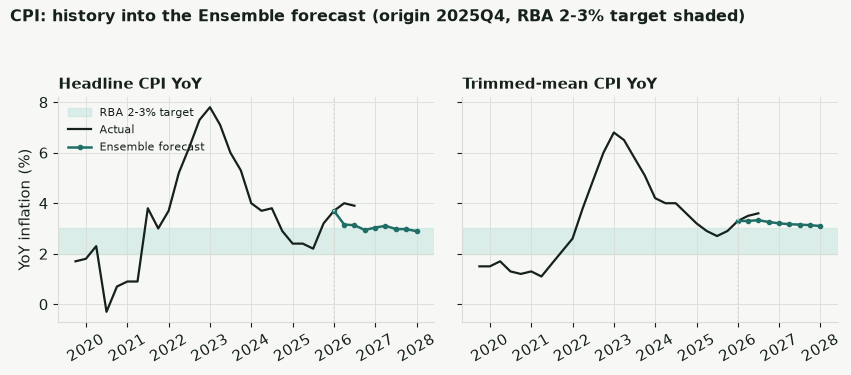

Actuals continue past the forecast origin as new ABS releases land -- a live read on how the forecast is tracking, not used to retrain the pinned model.


In [2]:
hist = pd.read_csv(TABLEAU / "historical_indicators.csv")
fc = pd.read_csv(TABLEAU / "forecast.csv")
fc_ens = fc[fc["model_family"] == "ensemble"].copy()
origin = fc_ens["forecast_origin"].iloc[0]

panels = [
    ("cpi_yoy", "Headline", "Headline CPI YoY"),
    ("trimmed_mean_cpi_yoy", "Trimmed mean", "Trimmed-mean CPI YoY"),
]

fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.8), sharey=True)
for ax, (variable, target_label, title) in zip(axes, panels):
    h = hist[hist["variable"] == variable].sort_values("quarter").tail(28).copy()
    h["quarter_date"] = pd.PeriodIndex(h["quarter"], freq="Q").to_timestamp(how="end")
    f = fc_ens[fc_ens["target"] == target_label].sort_values("horizon").copy()
    f["quarter_date"] = pd.PeriodIndex(f["quarter"], freq="Q").to_timestamp(how="end")

    origin_row = h[h["quarter"] == origin].iloc[0]
    ax.axhspan(2, 3, color=ACCENT_SOFT, alpha=0.5, zorder=0, label="RBA 2-3% target")
    ax.plot(h["quarter_date"], h["value"], color=INK, linewidth=1.6, label="Actual")
    fx = pd.concat([pd.Series([origin_row["quarter_date"]]), f["quarter_date"]], ignore_index=True)
    fy = pd.concat([pd.Series([origin_row["value"]]), f["forecast"]], ignore_index=True)
    ax.plot(fx, fy, color=ACCENT, linewidth=1.8, marker="o", markersize=3, label="Ensemble forecast")
    ax.axvline(origin_row["quarter_date"], color=GRID, linewidth=1.2, linestyle=":")
    ax.set_title(title, loc="left", fontsize=11, fontweight="bold")
    ax.tick_params(axis="x", rotation=30)

axes[0].set_ylabel("YoY inflation (%)")
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
fig.suptitle(f"CPI: history into the Ensemble forecast (origin {origin}, RBA 2-3% target shaded)",
             x=0.01, ha="left", fontsize=11.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()
print("Actuals continue past the forecast origin as new ABS releases land -- a live read on "
      "how the forecast is tracking, not used to retrain the pinned model.")

In [3]:
mc = pd.read_csv(TABLEAU / "model_comparison.csv")
cov = pd.read_csv(TABLEAU / "model_interval_coverage.csv")
summary = mc.merge(
    cov[["target", "model", "empirical_coverage", "significantly_miscalibrated"]],
    on=["target", "model"], how="left",
)
summary["rmse"] = summary["rmse"].round(3)
summary["empirical_coverage"] = (summary["empirical_coverage"] * 100).round(1)
summary = summary.rename(columns={
    "rmse": "RMSE", "empirical_coverage": "80% interval coverage (%)",
    "significantly_miscalibrated": "Below nominal?",
})
summary.sort_values(["target", "RMSE"])[
    ["target", "model", "RMSE", "80% interval coverage (%)", "Below nominal?"]
].reset_index(drop=True)

,target,model,RMSE,80% interval coverage (%),Below nominal?
0,Headline,ensemble,1.640,66.3,True
1,Headline,sarima,1.653,75.3,True
2,Headline,elastic_net,1.706,67.7,True
3,Headline,seasonal_naive,2.163,NaN,NaN
4,Trimmed mean,ensemble,1.273,45.0,True
5,Trimmed mean,sarima,1.299,67.9,True
6,Trimmed mean,elastic_net,1.426,47.9,True
7,Trimmed mean,seasonal_naive,1.581,NaN,NaN


**Limitation.** The Ensemble has the lowest RMSE on both targets, a real if modest
improvement from combining models — but every family's 80% interval sits below its nominal
coverage, most severely on trimmed-mean Ensemble. An overconfident interval is the specific
failure mode that would hurt a rate-risk use case, so it's shown plainly above rather than
only as a point forecast.

### Front 2 — mistimed RBA policy positioning

**Built:** seven readings of the same cut/hold/hike decision — a threshold baseline, two
Taylor-rule variants, ordered logit/probit, Frank-Hall ordinal XGBoost, and a majority-vote
ensemble.

In [4]:
rba = pd.read_csv(TABLEAU / "rba_action.csv")
print(f"Forecast origin {rba['forecast_origin'].iloc[0]} -> target {rba['target_quarter'].iloc[0]}: "
      f"the reportable call is \'{rba['reportable_action'].iloc[0]}\' ({rba['reportable_model'].iloc[0]}).")

lines = (PROJECT_ROOT / "reports/rba_classifier_evaluation.md").read_text().splitlines()
start = next(i for i, l in enumerate(lines) if l.startswith("| model") and "macro_f1" in l)
rows = []
for l in lines[start:]:
    if not l.startswith("|"):
        break
    rows.append(l)
header = [c.strip() for c in rows[0].strip("|").split("|")]
data = [[c.strip() for c in r.strip("|").split("|")] for r in rows[2:]]
macro_f1 = pd.DataFrame(data, columns=header).astype({"macro_f1": float, "accuracy": float, "n": int})
macro_f1.sort_values("macro_f1", ascending=False).reset_index(drop=True)

Forecast origin 2025Q4 -> target 2026Q1: the reportable call is 'hike' (threshold).


,model,macro_f1,accuracy,n
0,threshold,0.775,0.756,41
1,majority_vote_ensemble,0.769,0.732,41
2,taylor_rule_estimated,0.769,0.732,41
3,ordered_logit,0.715,0.683,41
4,ordered_probit,0.696,0.659,41
5,taylor_rule,0.365,0.415,41
6,frank_hall_xgboost,0.274,0.366,41


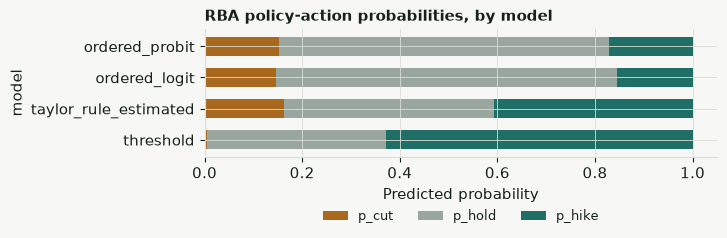

In [5]:
probs = rba.dropna(subset=["p_cut"]).set_index("model")[["p_cut", "p_hold", "p_hike"]]

fig, ax = plt.subplots(figsize=(7.4, 2.8))
probs.plot(kind="barh", stacked=True, ax=ax, color=[HIGHLIGHT, "#9aa79f", ACCENT], width=0.6)
ax.set_xlabel("Predicted probability")
ax.set_title("RBA policy-action probabilities, by model", loc="left", fontsize=11, fontweight="bold")
ax.legend(frameon=False, ncol=3, fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.32))
fig.tight_layout()
plt.show()

**Limitation.** The transparent threshold baseline is the reportable model — but its lead
over ordered logit/probit and the majority-vote ensemble is not statistically significant
(paired-bootstrap 95% confidence intervals cross zero). The honest claim is "a simple,
transparent baseline holds its own against more complex classifiers," not "we built a
superior RBA-prediction model," and it's a comparison exercise on historical decisions, not
a live validated track record.

### Front 3 — understated credit losses

**Built:** an illustrative 12-month AASB 9 expected credit loss (ECL), stressing NAB's own
disclosed probability of default (Pillar 3, Table CR6) with unemployment-sensitivity
coefficients from a published RBA research paper, using NAB's own disclosed loss-given-
default and exposure-at-default plus an RBA-sourced discount rate, blended across
downside/base/upside scenarios at NAB's own disclosed probability weights.

In [6]:
credit = pd.read_csv(TABLEAU / "credit_stress.csv")

downside = credit[credit["scenario"] == "downside"][["segment", "pd_base", "pd_stressed"]].drop_duplicates()
downside["PD (base)"] = (downside["pd_base"] * 100).round(2).astype(str) + "%"
downside["PD (downside stress)"] = (downside["pd_stressed"] * 100).round(2).astype(str) + "%"

weighted = credit.drop_duplicates("segment")[["segment", "ecl_aud_m_12m_probability_weighted"]].copy()
weighted["ecl_aud_m_12m_probability_weighted"] = weighted["ecl_aud_m_12m_probability_weighted"].round(1)
weighted = weighted.rename(columns={"ecl_aud_m_12m_probability_weighted": "Probability-weighted 12m ECL ($AUDm)"})

kpi = downside[["segment", "PD (base)", "PD (downside stress)"]].merge(weighted, on="segment")
kpi.rename(columns={"segment": "Segment"}).reset_index(drop=True)

,Segment,PD (base),PD (downside stress),Probability-weighted 12m ECL ($AUDm)
0,personal_loans,8.78%,9.17%,104.6
1,mortgages,2.07%,2.66%,1588.6


**Limitation, the one to be most careful not to overstate:** this figure is **not**
comparable to NAB's real provision, and is larger than it in an explainable, not alarming,
way. It's a 12-month, Stage-1-only calculation with no staging logic, applied to the full
exposure rather than a genuine Stage-1 subset — structurally inflated versus a real
provision by construction. NAB's real Stage 1 provision was $646 million of a $6,165
million Group total (roughly 10.5%); this project's illustrative mortgages ECL above is
larger than that *and* larger than NAB's real total (all-stage) Housing provision of $1.296
billion. It is not a lower bound on, or any kind of estimate of, NAB's real ECL, and it is
not for actual credit or regulatory decisions.

### The connecting piece — SVAR and the Scenario Engine

SVAR supplies the unemployment scenario Credit Stress consumes directly, and feeds the
Scenario Engine's "what if" shocks to CPI. Three of the four shock channels are cleanly
signed (unemployment up → CPI down, commodity growth up → CPI up, inflation expectations
up → CPI up); the cash-rate channel shows a well-documented "price puzzle" artifact of this
model class, not a bug. But both underlying VAR systems still fail their own multivariate
residual whiteness and normality diagnostics, so everything downstream of SVAR — including
every Scenario Engine output — is illustrative, not causal.

### Grounded in real disclosures, not invented assumptions

Every business figure above is sourced, not assumed: NAB's own FY2025 disclosures (Pillar
3 and Annual Report) supply the default, loss, exposure, and scenario-weighting inputs, and
a peer-reviewed Reserve Bank of Australia research paper supplies the unemployment
sensitivity used to stress them.

### Read on

The rest of this book walks through the full CRISP-DM pipeline behind these numbers, with
every equation followed by a plain-English explanation — starting with Business
Understanding. To jump straight to a model: SARIMA, Elastic Net, and Ensemble are §4.1–4.3;
SVAR and the Scenario Engine are §4.4–4.5; the RBA Policy Classifier is §4.6; Credit Stress
is §4.7.